In [1]:
from fredapi import Fred
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR
import pandas as pd
from scipy.stats import kurtosis, skew
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


from sklearn.model_selection import train_test_split
np.random.seed(0)

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def assess_normality(data):
    """
    This function takes an NxM matrix 'data' and plots histograms and Q-Q plots for each column,
    and performs the Shapiro-Wilk test to assess normality.
    
    Parameters:
    data (np.array): An NxM numpy array where each column will be tested for normality.
    
    Returns:
    None
    """
    num_columns = data.shape[1]
    fig, axs = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))
    
    if num_columns == 1:
        axs = np.array([axs])  # Ensure axs is always 2D array for consistency
    
    for i in range(num_columns):
        # Histogram
        axs[i, 0].hist(data[:, i], bins='auto', color='#0504aa', alpha=0.7, rwidth=0.85)
        axs[i, 0].set_title(f'Histogram for Column {i+1}')
        axs[i, 0].set_ylabel('Frequency')
        axs[i, 0].set_xlabel('Value')
        
        # Q-Q plot
        stats.probplot(data[:, i], dist="norm", plot=axs[i, 1])
        axs[i, 1].set_title(f'Q-Q Plot for Column {i+1}')
        
        # Perform Shapiro-Wilk Test
        shapiro_test = stats.shapiro(data[:, i])
        print(f"Shapiro-Wilk Test for Column {i+1}: Statistic={shapiro_test[0]}, P-value={shapiro_test[1]}")
    
    plt.tight_layout()
    plt.show()



def col_names(mats):
        return [f'{m*12:.0f}m' for m in mats]
def make_nss_yield_df(start_date= '1986-12-01', end_date = '2012-01-01', max_maturity = 120):
    df = pd.read_csv('feds200628.csv', skiprows=9)
    df = df[['Date', 'BETA0', 'BETA1', 'BETA2', 'BETA3', 'TAU1', 'TAU2']]
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.query('Date > "1980-01-01"')
    
    # Calculate the yields using the NSS formula for each maturity directly
    n_years = np.arange(1,max_maturity+1) / 12
    yields = np.empty((len(df), len(n_years)))
    for i, n in enumerate(n_years):
        term1 = (1 - np.exp(-n / df['TAU1'])) / (n / df['TAU1'])
        term2 = np.exp(-n / df['TAU1'])
        term3 = (1 - np.exp(-n / df['TAU2'])) / (n / df['TAU2'])
        term4 = np.exp(-n / df['TAU2'])
        yields[:, i] = df['BETA0'] + df['BETA1'] * term1 + df['BETA2'] * (term1 - term2) + df['BETA3'] * (term3 - term4)
    
    
    
    
    yields_df = pd.DataFrame(yields, columns=col_names(n_years), index=pd.to_datetime(df['Date']))
    yields_df = yields_df.loc[start_date:end_date].resample('BM').last() / 100
    return yields_df

def make_yield_df(start_date= '1986-12', end_date = '2012-01', max_maturity = 120, freq= 'monthly'):
    if freq == 'monthly':
        pure_data = pd.read_csv('yield_panel_monthly_frequency_monthly_maturity.csv', index_col=0).query(f'MAX_DATA_TTM > {max_maturity}').iloc[:,1:max_maturity+1]
    else:
        pure_data = pd.read_csv('yield_panel_daily_frequency_monthly_maturity.csv', index_col=0).query(f'MAX_DATA_TTM > {max_maturity}').iloc[:,1:max_maturity+1]
    pure_data.index = pd.to_datetime(pure_data.index)
    pure_data = pure_data.loc[start_date:end_date]
    return pure_data



def make_df_rx(yields_df: pd.DataFrame, rx_maturities):
    
    #display(yields_df)
    # Assuming the yield of the shortest maturity as the risk-free rate (in decimal form)
    
    # Compute log prices (-n * yield) for continuously compounded yield
    log_prices = -yields_df.values * np.arange(1, yields_df.shape[1]+1)/12
    assert sum(abs(-yields_df.values[:,2] * 0.25 - log_prices[:,2])) < 1.e-6 # assert scaling is correctly applied to data
    #log_prices = log_prices.values
    rfr_t = -log_prices[:-1,0] #       get time 0, 1,..., T-1 and maturity 1 
    p_t_n = log_prices[:-1, 1:] #     get time 0, 1,..., T-1 and maturities 2, 3,.., N. 
    p_tp1_nm1 = log_prices[1:, :-1] # get time 1, 2,..., T   and maturities 1, 2,.., N-1
    
    rx = p_tp1_nm1 - p_t_n - rfr_t.reshape(-1,1)
    rx_maturities_idx = rx_maturities - 2

    df_rx = pd.DataFrame(rx[:,rx_maturities_idx], columns = col_names(rx_maturities/12), index=yields_df.index[1:])
    
    return df_rx



def MLS(Y, Z):
    assert Y.shape[0] < Y.shape[1]
    assert Z.shape[0] < Z.shape[1]
    phi = Y@np.linalg.pinv(Z)
    Y_fitted = phi@Z
    residuals = Y-Y_fitted
    return phi, Y_fitted, residuals






In [3]:


def fit_AE(df_yields, autoencoder, n_epochs=50, smoothness_penalty_scale = 0.1,lr=0.001, verbose = False, plot_loss=False, return_loss = False, betas=(0.9,0.999), gamma=1, fast = False, train_pct = 100):
    if type(df_yields) == pd.DataFrame:
        pure_data_vals = df_yields.values
        X_maturities_idx = np.arange(2, 120, 1) # subtract due to 0-indexing
        data = pure_data_vals[:,X_maturities_idx].copy() # 1000 samples of 120-month yield curves
    else:
        data = df_yields
    
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)  # if you are using multi-GPU.
    torch.manual_seed(42)

   


    # Dummy data for example purposes
    
    scaler = StandardScaler()
    data = scaler.fit_transform(data)
    #print(data)
    

    # Assuming `data` is your dataset array where each row is a yield curve
    #data_train, data_test = train_test_split(data, test_size=0, random_state=42, shuffle=False)
    train_len = int(len(data)*train_pct/100)
    #print(train_len, len(data))
    data_train, data_test = data[:train_len], data[train_len:]#train_test_split(data, test_size=0, random_state=42, shuffle=False)
    #print(len(data_test))
    if torch.cuda.is_available():
        print("cuda available!")
        torch.set_default_tensor_type('torch.cuda.FloatTensor')
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Penalty and device helper functions
    def smoothness_penalty(outputs, lambda_smooth=smoothness_penalty_scale):
        diff_slope = outputs[:, 2:] - 2 * outputs[:, 1:-1] + outputs[:, :-2]
        smoothness_loss = torch.mean(diff_slope**2)
        return lambda_smooth * smoothness_loss

    

    # Model, optimizer, and scheduler setup
    autoencoder = autoencoder.to(device)
    optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr, betas=betas)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=gamma)
    criterion = nn.MSELoss()


    if fast:
        data_train_tensor = torch.tensor(data, dtype=torch.float32)
        #train_dataset = TensorDataset(data_train_tensor, data_train_tensor)

        for epoch in range(n_epochs):
            autoencoder.train()  # Ensure the network is in training mode

            inputs, targets = data_train_tensor, data_train_tensor
            inputs, targets = inputs.to(device), targets.to(device)  # Move data to the appropriate device
            optimizer.zero_grad()  # Clear previous gradients
            outputs = autoencoder(inputs)
            #print(smoothness_penalty(outputs=outputs))
            loss = criterion(outputs, targets) + smoothness_penalty(outputs=outputs)

            loss.backward()  # Backpropagate the error
            optimizer.step()  # Update the weights
            train_loss = loss.item()  # Loss from the last batch (not used for reporting)

            scheduler.step()  # Adjust the learning rate
        print(f'Epoch {epoch+1}, Average Training Loss: {loss.item():.8f}')

    
    else:
        # Convert datasets to PyTorch tensors
        data_train_tensor = torch.tensor(data_train, dtype=torch.float32)
        #mean_train = torch.mean(data_train_tensor, dim=0)
        #data_train_tensor = torch.tensor(data_train, dtype=torch.float32) - mean_train
        data_test_tensor = torch.tensor(data_test, dtype=torch.float32)
        #mean_test = torch.mean(data_test_tensor, dim=0)
        #data_test_tensor = torch.tensor(data_test, dtype=torch.float32) - mean_test

        # Create datasets and dataloaders
        train_dataset = TensorDataset(data_train_tensor, data_train_tensor)  # Assuming input and target are the same
        if train_pct == 100:
            test_dataset = TensorDataset(data_train_tensor, data_train_tensor)
        else:
            test_dataset = TensorDataset(data_test_tensor, data_test_tensor)
        train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False, drop_last=True)
        test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

        

        # Function to validate model
        def validate_model(model, loader, device):
            model.eval()
            total_loss = 0
            with torch.no_grad():
                for inputs, targets in loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    outputs = model(inputs)
                    total_loss += criterion(outputs, targets).item() * inputs.size(0)
                #print(len(loader.dataset))
            return total_loss / len(loader.dataset)

        # Training loop
        val_loss_list = []
        loss_list = []
        for epoch in range(n_epochs):
            autoencoder.train()  # Ensure the network is in training mode
            total_loss = 0
            total_batches = 0

            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)  # Move data to the appropriate device
                optimizer.zero_grad()  # Clear previous gradients
                outputs = autoencoder(inputs)
                #print(smoothness_penalty(outputs=outputs))
                loss = criterion(outputs, targets) + smoothness_penalty(outputs=outputs)

                loss.backward()  # Backpropagate the error
                #nn.utils.clip_grad_norm_(autoencoder.parameters(), 0.5)
                optimizer.step()  # Update the weights

                total_loss += loss.item()
                total_batches += 1

            average_train_loss = total_loss / total_batches  # Calculate the average loss for the epoch
            train_loss = loss.item()  # Loss from the last batch (not used for reporting)
            val_loss = validate_model(autoencoder, test_loader, device)  # Validate the model

            # Logging
            if verbose or epoch >= n_epochs - 2:
                print(f'Epoch {epoch+1}, Average Training Loss: {average_train_loss:.8f}, Validation Loss: {val_loss:.8f}')
            loss_list.append(average_train_loss)
            val_loss_list.append(val_loss)
            
            scheduler.step()  # Adjust the learning rate

        # Plotting the training and validation loss
        if plot_loss:
            plt.figure(figsize=(10, 5))
            plt.plot(np.arange(n_epochs), loss_list, label='Training Loss')
            plt.plot(np.arange(n_epochs), val_loss_list, label='Validation Loss')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.yscale('log')  # Use logarithmic scale if appropriate
            plt.title('Loss Over Epochs')
            plt.legend()
            plt.grid(True)
            plt.show()

    # Processing the full dataset after training
    autoencoder.eval()
    encoded_data = autoencoder.encoder(data_train_tensor.to(device))
    decoded_data = np.array(autoencoder.decoder(encoded_data).cpu().detach())
    X_AE_full = np.array(encoded_data.cpu().detach()).T
    #plt.plot(encoded_data.cpu().detach())
    #plt.show()
    # Optionally return the last training loss
    Q, R = np.linalg.qr(X_AE_full.T)
    scaler = StandardScaler()
    Q = scaler.fit_transform(Q)

    if return_loss:
        return train_loss

    return Q.T, decoded_data

EXPECTED RETURNS ERROR: 0.007712900663085038
DatetimeIndex(['2011-12-30'], dtype='datetime64[ns]', freq=None)
std deviation of yields over 1 month 0.0016417367484733332


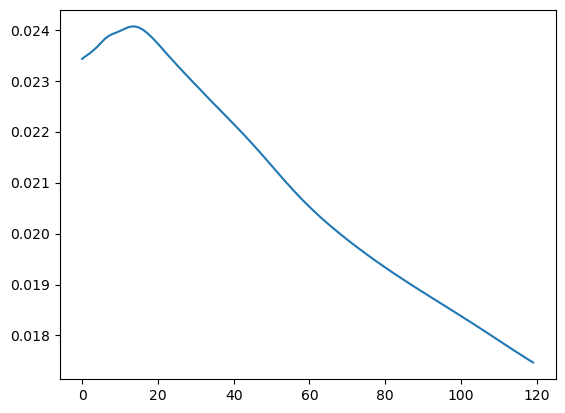

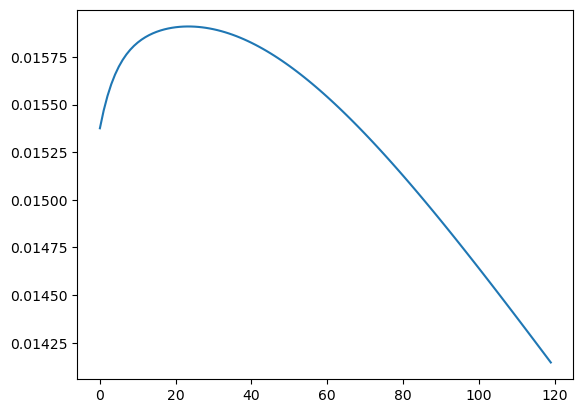

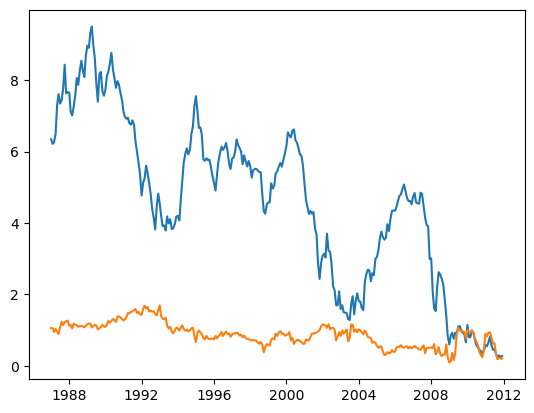

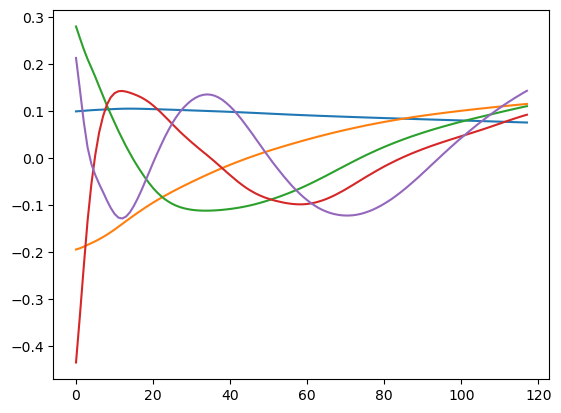

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 16, Apr, 2024
Time:                     21:29:00
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -10.4423
Nobs:                     300.000    HQIC:                  -10.6644
Log likelihood:          -476.510    FPE:                2.01436e-05
AIC:                     -10.8127    Det(Omega_mle):     1.82446e-05
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.009393         0.007700           -1.220           0.223
L1.y1         0.996602         0.007754          128.533           0.000
L1.y2        -0.002597         0.007712           -0.337           0.736
L1.y3        -0.006401

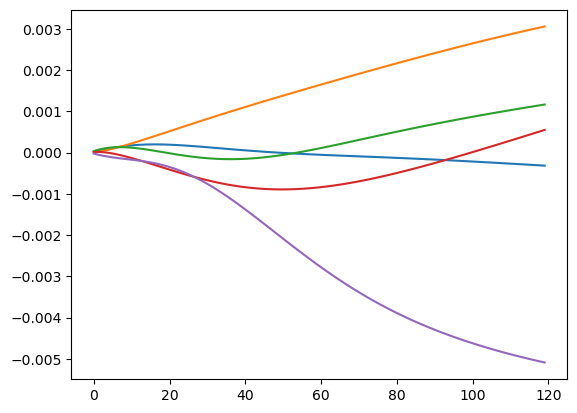

In [134]:


from dataclasses import dataclass
def estimate_X_full_PCA(df_yields, n_components=5, return_obj=False):
    pca_whiten = PCA(n_components=n_components, whiten=True)

    X_maturities_idx = np.arange(3, 121, 1)-1 # subtract due to 0-indexing
    pca_data = df_yields.iloc[:, X_maturities_idx]
    
    X_full = pca_whiten.fit_transform(pca_data).T
    #print(np.mean(X_full, axis=1))
    if return_obj:
        return X_full, pca_whiten
    else:
        return X_full

@dataclass
class Step1Reg:
    mu: np.ndarray = None
    phi: np.ndarray = None
    X_fitted: np.ndarray = None
    V_hat: np.ndarray = None
    cap_sigma_hat: np.ndarray = None
    X: np.ndarray = None
    X_: np.ndarray = None
    T : int = None
    K : int = None
    result = None
    
    def regress(self, X_full, use_libs=False):
        X = X_full[:,1:].copy()
        X_ = X_full[:, :-1].copy()
        K, T = X_.shape
        self.T = T
        self.K = K

        if use_libs:
            model = VAR(X_full.T)
            results = model.fit(1)  # Fit VAR(1)
            self.result = results
            
            self.phi = results.params[1:].T  # AR coefficients
            self.mu = results.params[:1].T  # Intercept terms
            self.X_fitted = results.fittedvalues.T
            self.V_hat = results.resid.T

            self.cap_sigma_hat = np.cov(self.V_hat)  # Covariance matrix of residuals
        else: 

            phi, self.X_fitted, V_hat = MLS(Y=X, Z=np.vstack((np.ones((1,T)), X_)))
            self.mu = phi[:,[0]]

            self.phi = phi[:,1:]
            self.V_hat = V_hat
            self.X = X
            self.X_ = X_

            self.cap_sigma_hat = (V_hat @ V_hat.T)/T
        
        return self

@dataclass
class Step2Reg:
    rx_mat: np.ndarray = None
    rx_pred: np.ndarray = None
    E_hat: np.ndarray = None
    a_hat: np.ndarray = None
    beta_hat: np.ndarray = None
    c_hat: np.ndarray = None
    N : np.ndarray = None
    
  
    def regress(self, df_rx, step1: Step1Reg):
        self.rx_mat = df_rx.values.T
        N = self.rx_mat.shape[0]
        K = step1.K
        T = step1.T
        Z_tilde = np.vstack((np.ones((1,step1.T)),step1.V_hat,  step1.X_))
        abc, self.rx_pred, E_hat = MLS(Y=self.rx_mat, Z=Z_tilde)
        self.E_hat = E_hat
        a_hat, beta_hat, c_hat = abc[:,[0]], abc[:,1:K+1].T, abc[:,K+1:]
        self.sigma_sq_hat =  np.trace(E_hat @ E_hat.T) / (N * T)
        self.B_star = np.hstack([np.outer(beta_hat[:,i],beta_hat[:,i]).reshape(-1,1) for i in range(N)]).T
        
        self.a_hat = a_hat  
        self.beta_hat = beta_hat
        self.c_hat = c_hat
        return self
    

@dataclass
class Step3Reg:
    lambda_0_hat: np.ndarray = None
    lambda_1_hat: np.ndarray = None
    def get_results(self, step1:Step1Reg, step2: Step2Reg):
        a_hat, beta_hat, c_hat, B_star, sigma_sq_hat = step2.a_hat, step2.beta_hat, step2.c_hat, step2.B_star, step2.sigma_sq_hat
        
        vec_cap_sigma_hat = step1.cap_sigma_hat.reshape(-1,1)
        beta_proj = np.linalg.inv(beta_hat@beta_hat.T)@beta_hat

        self.lambda_0_hat =  beta_proj@(a_hat + 1/2*(B_star@vec_cap_sigma_hat + sigma_sq_hat))
        self.lambda_1_hat = beta_proj@c_hat
        return self

@dataclass
class ATSM:
    log_prices_fitted: np.ndarray = None
    yields_fitted: np.ndarray = None

    def create_model(self, step1:Step1Reg, step2: Step2Reg, step3: Step3Reg,df_yield,  max_maturity = 120):
        K, T = step1.K, step1.T
        X_, phi, mu, cap_sigma_hat = step1.X_.copy(), step1.phi.copy(), step1.mu.copy(), step1.cap_sigma_hat.copy()
        sigma_sq_hat = step2.sigma_sq_hat
        lambda_0_hat, lambda_1_hat = step3.lambda_0_hat.copy(), step3.lambda_1_hat.copy()


        A = np.zeros((1,max_maturity))
        A_rf = np.zeros((1,max_maturity))
        B = np.zeros((K, max_maturity))
        B_rf = np.zeros((K, max_maturity))
        rfr_arr = 1/12*df_yield.copy().values[:-1,0].reshape(1,-1) # scale to reflext maturity
        ab, rfr_arr_hat, u = MLS(rfr_arr, np.vstack((np.ones((1,T)),X_)))
        delta_0 = ab[0,0]
        delta_1 = ab[0, 1:]

        A[0,0] = -delta_0
        B[:,0] = -delta_1
        A_rf[0,0] = -delta_0
        B_rf[:,0] = -delta_1
        for i in range(1, max_maturity):
            A[0, i] = A[0, [i-1]] + B[:, [i-1]].T @ (mu - lambda_0_hat) + 0.5 * (B[:, [i-1]].T @ cap_sigma_hat @ B[:, [i-1]] +  sigma_sq_hat) - delta_0
            B[:, i] = B[:,[i-1]].T@(phi-lambda_1_hat) - delta_1

            A_rf[0, i] = A_rf[0, [i-1]] + B_rf[:, [i-1]].T @ mu + 0.5 * (B_rf[:, [i-1]].T @ cap_sigma_hat @ B_rf[:, [i-1]] +  sigma_sq_hat) - delta_0
            B_rf[:, i] = B_rf[:,[i-1]].T@phi - delta_1
        maturities = np.arange(1, max_maturity + 1) / 12 # divide by 12 to get maturity in year unit
        
        self.log_prices_fitted = (A.T + B.T@X_)
        self.yields_fitted = -(A.T + B.T@X_).T / maturities
        self.B = B
        self.A = A
        self.B_rf = B_rf
        self.A_rf = A_rf
        self.delta_0 = delta_0
        self.delta_1 = delta_1
        return self


class ACM:
    def __init__(self, df_yields, df_rx, X_full, AE: bool):
        self.df_yields = df_yields
        self.X_full = X_full
        self.df_rx = df_rx
        self.AE = AE
        self.yields_fitted = None
        self.log_prices_fitted = None
        self.step1 = None
        self.step2 = None
        self.step3 = None
        self.atsm = None




    def estimate_ACM(self) -> 'ACM':


        self.step1 = Step1Reg().regress(X_full=self.X_full)
        self.step2 = Step2Reg().regress(df_rx=self.df_rx, step1=self.step1)
        self.step3 = Step3Reg().get_results(step1=self.step1, step2=self.step2)
        self.atsm = ATSM().create_model(step1=self.step1, step2=self.step2, step3=self.step3, df_yield=self.df_yields, max_maturity=self.df_yields.shape[1])
       
        np.set_printoptions(precision=3)

        return self
    

            



    def evaluate_atsm(self, extrapol_len = 240, plot_B_v_beta = False, plot_B_v_beta_PCA=False, enforced_PCA_dims=0):
        if enforced_PCA_dims:
            pca_whiten = PCA(n_components=enforced_PCA_dims, whiten=True)
        else:
            pca_whiten = PCA(n_components=self.X_full.shape[0], whiten=True)

        X_maturities_idx = np.arange(3, 121, 1)-1 # subtract due to 0-indexing
        pca_data = self.df_yields.iloc[:, X_maturities_idx]

        X_full_PCA = pca_whiten.fit_transform(pca_data).T
        
        pca_acm = ACM(df_yields=self.df_yields, df_rx=self.df_rx, X_full= X_full_PCA, AE=False).estimate_ACM()

        end_date = self.df_yields.index[-1].date()
        print("USING ML SMOOTHED DATASET")
        df_yields_extra = make_yield_df(max_maturity=extrapol_len, end_date=end_date)

        pca_atsm = ATSM().create_model(step1=pca_acm.step1, step2=pca_acm.step2, step3=pca_acm.step3, df_yield=self.df_yields, max_maturity=extrapol_len)        

        atsm = ATSM().create_model(step1=self.step1, step2=self.step2, step3=self.step3, df_yield=self.df_yields, max_maturity=extrapol_len)
        
        pca_avg_yields = np.mean(pca_atsm.yields_fitted, axis=0)
        avg_yields = np.mean(df_yields_extra.values, axis=0)
        atsm_avg_yields = np.mean(atsm.yields_fitted, axis=0)
        

        plt.plot(100*avg_yields, linestyle='dashdot', label='observed')
        plt.plot(100*atsm_avg_yields, label= f"AE:   {np.mean(np.abs(atsm_avg_yields- avg_yields)):.7f}")
        plt.plot(100*pca_avg_yields, linestyle='--', label= f"PCA: {np.mean(np.abs(pca_avg_yields- avg_yields)):.7f}")
        plt.grid()
        plt.legend()
        plt.show()
        beta_hat = self.step2.beta_hat
        B = atsm.B
        K = self.X_full.shape[0]
        if plot_B_v_beta:
            for i in range(K):
                
                print(np.sqrt(np.mean(np.square(beta_hat[i] - B[i,np.array([6,12,18,24,30,36,42,48,52,60,84,120])-1]))))
                plt.scatter([6,12,18,24,30,36,42,48,52,60,84,120], beta_hat[i], color='orange')
                plt.plot([6,12,18,24,30,36,42,48,52,60,84,120], beta_hat[i], color='orange')
                plt.plot(B[i])
                plt.show()
        
        if plot_B_v_beta_PCA:
            beta_hat = pca_acm.step2.beta_hat
            B = pca_atsm.B
            K = pca_acm.X_full.shape[0]
            print("======= PCA BELOW ==========")
            for i in range(K):
                
                print(np.sqrt(np.mean(np.square(beta_hat[i] - B[i,np.array([6,12,18,24,30,36,42,48,52,60,84,120])-1]))))
                plt.scatter([6,12,18,24,30,36,42,48,52,60,84,120], beta_hat[i], color='orange')
                plt.plot([6,12,18,24,30,36,42,48,52,60,84,120], beta_hat[i], color='orange')
                plt.plot(B[i])
                plt.show()

def forecast_short_rates(df_yields_full, model = None, AE=False, max_forecast_months=60, var_forecast = False):
    model = YieldCurveAutoencoder()
    # Predict future short rates up to max_forecast_months ahead
    import datetime as dt
    T_max = df_yields_full.shape[0] - max_forecast_months-2
    T_start = 12*10
    forecasts = np.zeros((T_max-T_start, max_forecast_months))
    actual = np.zeros((T_max-T_start, max_forecast_months))
    rv = np.zeros((T_max-T_start, max_forecast_months))
    rmse_forecast = np.zeros((T_max-T_start, max_forecast_months))
    display(df_yields_full.iloc[T_start:T_start+1,].index)
    RMSE_list = []
    for i, T in enumerate(range(T_start, T_max )):
        df_yields = df_yields_full.iloc[:T+2].copy()
        rx_maturities = np.array([6, 12, 18, 24, 30, 36, 42, 48,  54, 60, 84, 120])
        df_rx = make_df_rx(df_yields,  rx_maturities= rx_maturities)
        if AE:
            if i == 0:
                n_epochs = 1000
                lr=0.009
            else:
                n_epochs = 50
                lr = 0.002
            X_full, _ = fit_AE(df_yields=df_yields, autoencoder=model, n_epochs= n_epochs, lr=lr,smoothness_penalty_scale=0, plot_loss=True, gamma=0.9992, betas=(0.90,0.9995), fast=True)

        else:        
            X_full = estimate_X_full_PCA(df_yields=df_yields, n_components=5)
        
        
        acm = ACM(df_yields=df_yields, df_rx=df_rx, X_full=X_full, AE=True).estimate_ACM()

        A_rf, B_rf = acm.atsm.A_rf, acm.atsm.B_rf
        #mu, phi = acm.step1.mu, acm.step1.phi
        #delta_0, delta_1 = acm.atsm.delta_0, acm.atsm.delta_1  
        #lambda_0_hat, lambda_1_hat = acm.step3.lambda_0_hat, acm.step3.lambda_1_hat
        X_t = acm.step1.X_[:,[T]]
        
        #print(acm.step1.cap_sigma_hat)
        for s in range(1, max_forecast_months + 1):
            
            
            


            #X_t = mu + phi @ X_t  # Project state forward
            
            
            #r_t = delta_0 + delta_1 @ X_t  # Projected short rate
            
            r_t = -1/s*(A_rf[:,[s-1]] + B_rf[:,[s-1]].T@X_t)
            
            forecasts[i,s-1] =  100*12*r_t#.item() # Store forecast
            actual[i,s-1] =  100*np.mean(df_yields_full.iloc[T+1:T+1+s,0])
            rmse_forecast[i,s-1] = 100*df_yields_full.iloc[T+s,0]
            rv[i,s-1] =  100*df_yields_full.iloc[T,0] 
        if var_forecast:
                n_years_pred = 1
                data_end = (df_yields.index[-12]).date()
                pred_year = df_yields.index[-1].date()
                #print(data_end, pred_year)
                df_yields[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']] = X_full.T


                X_t = df_yields[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']].loc[str(data_end)].values.reshape(-1,1)
                #print("X_t date: ",df_yields[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']].loc[str(data_end)].tail(1).index)
                A = acm.atsm.A
                B = acm.atsm.B
                maturities = np.arange(1, 120 + 1) / 12
                pred_yields = np.zeros((len(maturities), int(n_years_pred*12)))

                for i in range(int(n_years_pred*12)-2):

                    X_t = acm.step1.mu + acm.step1.phi@X_t
                    pred_yields[:,i] =  -(A.T + B.T@X_t).T / maturities

                #print(len(pred_yields.T))
                actual_var = df_yields_full.iloc[:len(pred_yields.T)].values
                RMSE_list.append(np.sqrt(np.mean(np.square((pred_yields.T-actual_var)))))
                pred_yields = np.hstack((acm.atsm.yields_fitted.T, pred_yields))
                #print(len(df_yields_full.loc[:data_end  ].index), len(acm.atsm.yields_fitted), len(pred_yields.T))
                #display(pd.date_range(start=pred_year, freq='M', periods=n_years_pred).to_period('M').astype(str).to_list())
                pred_yields = pd.DataFrame(pred_yields.T, columns=df_yields_full.columns, index=df_yields_full.iloc[:len(pred_yields.T)].index)
    RMSE_VAR_FORECAST = np.mean(np.array(RMSE_list))
        
    return forecasts, actual, rv, rmse_forecast, RMSE_VAR_FORECAST



    



rx_maturities = np.array([6, 12, 18, 24, 30, 36, 42, 48,  54, 60, 84, 120])
#df_yields = make_nss_yield_df(end_date='2023')
class YieldCurveAutoencoder(nn.Module):
    def __init__(self):
        super(YieldCurveAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(118,5, bias=False),
            nn.Tanh(),
            nn.Linear(5,4, bias=False),
            #nn.Linear(118, 64),  # Reduce dimension from 120 to 64
            #nn.Tanh()
            #nn.Linear(64, 32),
            #nn.Tanh(),
            #nn.Linear(32, 5),    # Reduce dimension to 5 (bottleneck)
        )
        self.decoder = nn.Sequential(
            #nn.Linear(5, 32),   # Expand dimension from 5 to 32
            #nn.Tanh(),
            #nn.Linear(32,64),
            #nn.Tanh(),
            #nn.Linear(64, 118),  # Reconstruct the original 120-dimensional data
            #nn.Linear(5,64),
            #nn.ReLU(),
            nn.Linear(4, 118, bias=False)
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

class YieldCurveAutoencoderCNN(nn.Module):
    def __init__(self):
        super(YieldCurveAutoencoderCNN, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Unflatten(1,(1, 118)),                                          # Add channel dimension [Batch, Channel, Length]
            nn.Conv1d(1, 8, kernel_size=3, stride=1, padding=1),  # Output: (16, 118)
            nn.ReLU(),
            nn.MaxPool1d(2, stride=2),                            # Output: (16, 59)
            nn.Conv1d(8, 16, kernel_size=3, stride=1, padding=1), # Output: (32, 59)
            nn.ReLU(),
            nn.MaxPool1d(2, stride=2),                            # Output: (32, 29)
            nn.Flatten(),                                         # Output: (32*29)
            nn.Linear(16*29, 5)   
        )
        self.decoder = nn.Sequential(
            #nn.Linear(5, 16*4*8),  # Expand from 5 back to the flattened size
            nn.ReLU(),
            #nn.Unflatten(1, (16, 4, 8)),  # Unflatten to (C, H, W) = (16, 4, 8)
            #n.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output size: (1, 8, 15)
            #nn.Sigmoid(),
            #nn.Flatten(),  # Flatten to match the original padded input size of 120
            nn.Linear(5, 118)  # Adjust the final output to the required 118 size
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x




df_yields = make_yield_df(end_date='2011', freq='monthly')#
X_full, obj = estimate_X_full_PCA(df_yields=df_yields, n_components=5, return_obj=True)


#X_full_AE, reconst = fit_AE(df_yields=df_yields, autoencoder=YieldCurveAutoencoder(), n_epochs= 2000, lr=0.004,smoothness_penalty_scale=0, plot_loss=True, gamma=0.999, betas=(0.90,0.999), fast=True)

#train_len = int(len(df_yields)*.75)
#df_yields = df_yields[:train_len]
#X_full =
df_rx = make_df_rx(yields_df=df_yields, rx_maturities=rx_maturities)

#print(len(df_yields), len(df_rx), X_full_AE.shape)

results = ACM(df_yields=df_yields, df_rx=df_rx, X_full=X_full, AE=True).estimate_ACM()
#plt.plot(np.mean(reconst,axis=1))
#plt.plot(np.mean(df_yields.values,axis=0))
#plt.show()
print(f"EXPECTED RETURNS ERROR: {np.mean(np.square(df_rx.values.T-(results.step2.a_hat + results.step2.beta_hat.T@results.step1.X_)))}")

#results.evaluate_atsm(240, plot_B_v_beta=False, enforced_PCA_dims=4, plot_B_v_beta_PCA=False)

#pred, act, rw, rmse_forecast, RMSE = forecast_short_rates(df_yields_full=df_yields, AE=True, )
#plt.plot(pred)
#plt.show()
#plt.plot(act)
#plt.plot(np.sqrt(np.mean((np.square(act-pred).T), axis=1)), color='#0000ff')
#plt.plot(np.sqrt(np.mean((np.square(act-rw).T), axis=1)), label="rw", color='#bf00bf')
#plt.plot(np.sqrt(np.mean((np.square(rmse_forecast-rw).T), axis=1)), label="rw", color='red')
#plt.ylim(0,2)
#plt.yticks([0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2])
#plt.plot(np.mean(rmse_forecast.T, axis=1))
#plt.legend()
#plt.show()
#plt.plot()
#plt.plot(X_full.T)
#plt.plot(np.arange(5)+1,np.cumsum(obj.explained_variance_)/sum(obj.explained_variance_) )
#print(np.cumsum(obj.explained_variance_)/sum(obj.explained_variance_))
print(df_yields.tail(1).index)
print(f"std deviation of yields over 1 month {np.mean(np.abs(df_yields['1'].diff(1).dropna().values))}")
plt.plot(np.sqrt(np.mean(np.square(df_yields.values-np.mean(df_yields.values,axis=0).reshape(1,-1)), axis=0)))
#plt.plot(np.mean(df_yields.diff(1).dropna(),axis=0)*100)
#plt.plot(df_yields['1']*100)
plt.show()
max_maturity = 120
maturities = np.arange(1, max_maturity + 1) / 12
yields_rf = -(results.atsm.A_rf.T+results.atsm.B_rf.T@results.step1.X_).T/maturities
results.atsm.yields_fitted
plt.plot(yields_rf.T[:,212])
plt.show()
plt.plot(df_yields.iloc[:-1]['24']*100)
plt.plot((df_yields.iloc[:-1,:] -yields_rf)['24']*100)
plt.show()

plt.plot(obj.components_.T)
plt.show()
plt.plot((results.atsm.B.T@results.step3.lambda_1_hat))
Step1Reg().regress(X_full=X_full, use_libs=True).result.summary()

In [5]:
plt.plot(np.sqrt(np.mean((np.square(act-pred).T), axis=1)), label=f"model mean RMSE: {np.mean(np.sqrt(np.mean((np.square(act-pred).T), axis=1))):.3f}, {np.mean(np.sqrt(np.mean((np.square(act-pred).T), axis=1)))/np.mean(np.sqrt(np.mean((np.square(act-rw).T), axis=1)))*100:.1f}% of rw")
plt.plot(np.sqrt(np.mean((np.square(act-rw).T), axis=1)), linestyle='--', label=f"rw mean RMSE: {np.mean(np.sqrt(np.mean((np.square(act-rw).T), axis=1))):.3f}")
#plt.plot(np.mean(rmse_forecast.T, axis=1))
plt.legend()
plt.show()

NameError: name 'act' is not defined

cuda available!
Epoch 999, Average Training Loss: 0.00120275, Validation Loss: 0.00120252
Epoch 1000, Average Training Loss: 0.00120252, Validation Loss: 0.00120229


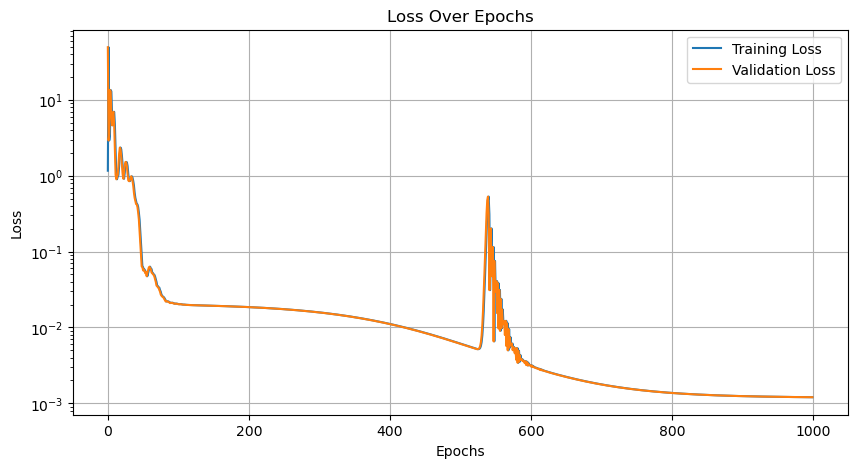

X_t date:  DatetimeIndex(['2018-12-31'], dtype='datetime64[ns]', freq=None)
385 384


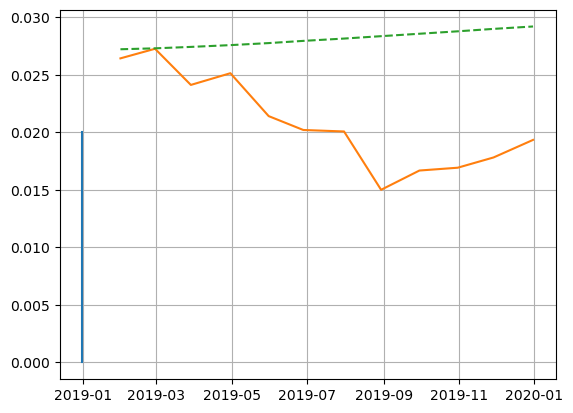

0.007331121459796856


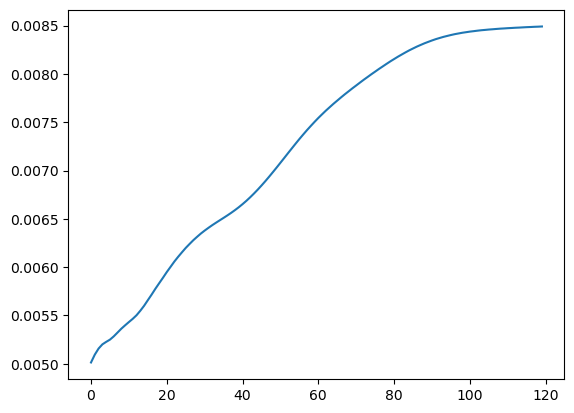

In [ ]:
def pred_1y_ahead(df_yields_full, AE=False, pred_year='2015', n_years_pred = 1):
    model = YieldCurveAutoencoder()
    data_end = str(int(pred_year)-1) # train on data up to and including prev year. 
    df_yields = df_yields_full.loc[:data_end].copy()
    rx_maturities = np.array([6, 12, 18, 24, 30, 36, 42, 48,  54, 60, 84, 120])
    df_rx = make_df_rx(df_yields,  rx_maturities= rx_maturities)
    if AE:
       
        n_epochs = 1000
        lr=0.09
      
        X_full, _ = fit_AE(df_yields=df_yields, autoencoder=model, n_epochs= n_epochs, lr=lr,smoothness_penalty_scale=0, plot_loss=True, gamma=0.9992, betas=(0.90,0.9995), fast=False, train_pct=100)

    else:        
        X_full = estimate_X_full_PCA(df_yields=df_yields, n_components=5)
    
    acm = ACM(df_yields=df_yields.copy(), df_rx=df_rx, X_full=X_full, AE=AE).estimate_ACM()
    acm.
    df_yields[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']] = X_full.T
    
    
    X_t = df_yields[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']].loc[data_end].tail(1).values.reshape(-1,1)
    print("X_t date: ",df_yields[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']].loc[data_end].tail(1).index)
    A = acm.atsm.A
    B = acm.atsm.B
    maturities = np.arange(1, 120 + 1) / 12
    pred_yields = np.zeros((len(maturities), int(n_years_pred*12)+1))
    
    for i in range(int(n_years_pred*12)+1):

        pred_yields[:,i] =  -(A.T + B.T@X_t).T / maturities
        X_t = acm.step1.mu + acm.step1.phi@X_t
    
    actual = df_yields_full.loc[str(int(pred_year)):str(int(pred_year)-1+n_years_pred)].values
    RMSE = np.sqrt(np.mean(np.square((pred_yields.T[1:]-actual)), axis=0))
    RMSE_total  = np.sqrt(np.mean(np.square((pred_yields[:,1:].T-actual))))
    pred_yields = np.hstack((acm.atsm.yields_fitted.T, pred_yields))
    print(len(df_yields_full.loc[:data_end  ].index), len(acm.atsm.yields_fitted))
    pred_yields = pd.DataFrame(pred_yields.T, columns=df_yields_full.columns, index=df_yields_full.loc[:str(int(pred_year)-1+n_years_pred)].index)

    return pred_yields, RMSE, RMSE_total


#preds = ACM(df_yields=df_yields, df_rx=df_rx, X_full=X_full, AE=False).estimate_ACM().pred_1y_ahead(pred_start='2018')
pred_year = 2019
n_years_pred = 1
mon=120
preds, RMSE, RMSE_total = pred_1y_ahead(df_yields_full=df_yields, pred_year=str(pred_year), n_years_pred=n_years_pred, AE=True)

pred_year = pred_year + n_years_pred
plt.plot([dt.date(pred_year-n_years_pred, 1, 30)- dt.timedelta(30), dt.date(pred_year-n_years_pred, 1, 30)- dt.timedelta(30)], [0,0.02])
plt.plot(df_yields.loc[str(pred_year-n_years_pred):str(pred_year-1) , f'{mon}'])
plt.plot(preds[f'{mon}'].loc[str(pred_year-n_years_pred):], linestyle='--')
plt.grid()
plt.show()
plt.plot(RMSE)
import datetime as dt
#print(df_yields.loc['2015'].tail(13).index)
print(RMSE_total)

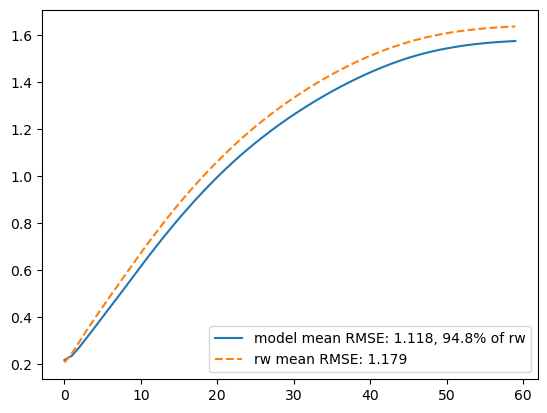

[[-0.064]
 [ 0.046]
 [ 0.012]
 [-0.039]
 [-0.009]] 

 [[ 6.879  8.557 -7.808 -4.378  3.773]
 [-8.489 -9.91   8.675  5.704 -3.949]
 [-2.879 -3.058  2.46   2.069 -1.063]
 [ 2.119  2.913 -2.802 -1.218  1.482]
 [ 2.702  3.343 -3.093 -1.738  1.373]]
[[-0.028]
 [ 0.023]
 [ 0.003]
 [-0.014]
 [-0.011]]


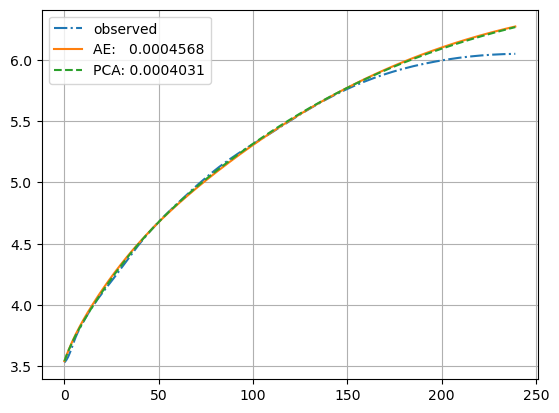

KeyError: '1m'

In [ ]:
print(results.step3.lambda_0_hat,"\n\n", results.step3.lambda_1_hat)
print(results.step1.mu)
results.evaluate_atsm(extrapol_len=240)
df_yields['1m'].plot()
df_yields['1m'].shift(50).plot()

plt.show()
for j in range(4,10):
    rmse = []
    for i in range(0,60):
        df_yields['forward_average_n'] = df_yields['1m'][::-1].rolling(window=i).mean()[::-1]

        # Shift the results back by n to align with the 'i' index
        df_yields['forward_average_n'] = df_yields['forward_average_n'].shift(-i)
        #rmse.append(np.sqrt(np.mean(np.square(df_yields['1m'].iloc[j*12:] -avg))))
        rmse.append(np.sqrt(np.mean(np.square(df_yields['1m'].iloc[j*12:] - df_yields['1m'].iloc[j*12:].shift(i)))))
        
    plt.plot(np.arange(len(rmse))+j*50,rmse , label=f'offset: {j} years')
plt.legend()
plt.show()

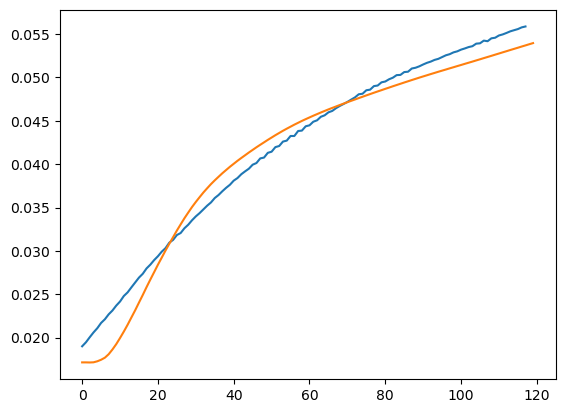

In [ ]:
asd = 180
plt.plot(reconst[asd])
plt.plot(df_yields.values[asd])

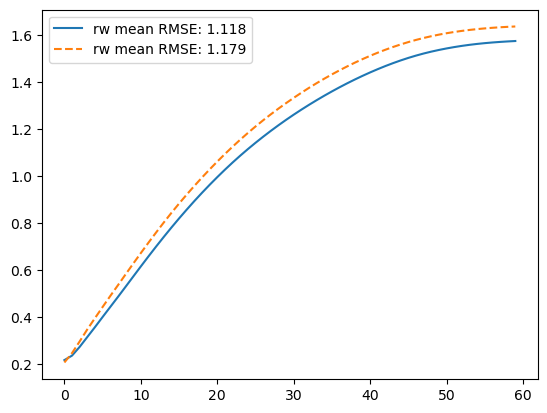

In [ ]:
#plt.plot(np.mean(np.abs(act - pred), axis=0))
n_mat = 5
trial = 4
#plt.plot(pred.T[:n_mat,trial])
#plt.plot(act.T[:n_mat,trial])
#plt.plot(rw.T[:n_mat,trial])
#plt.plot([60-1,60-1], [2,5])
#plt.plot(pred.T-act.T)
#plt.show()
#plt.plot(rw.T - act.T)





#plt.plot(np.mean(act, axis=1))

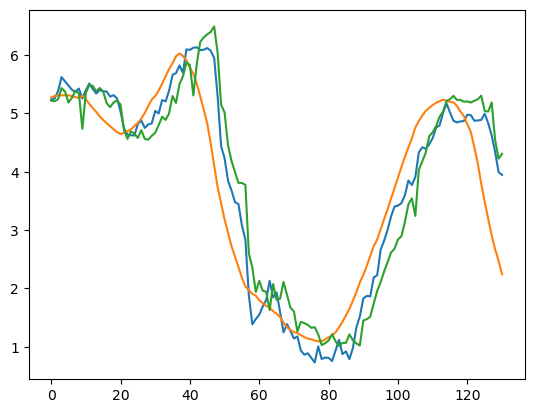

In [ ]:
plt.plot(pred[:,10])
plt.plot(act[:,10])
plt.plot(rw[:,10])

In [ ]:
def grid_search_ae(df_yields, autoencoder_model, param_grid):
    """
    Perform grid search over hyperparameters for an autoencoder model on yield curve data.

    Parameters:
    df_yields (DataFrame): The yield curve data.
    autoencoder_model (YieldCurveAutoencoder class): The autoencoder model class.
    param_grid (dict): Dictionary specifying the parameters to search and their corresponding list of values.

    Returns:
    list: A list of dictionaries with the parameters and the resulting error for each set.
    """

    # Initialize a list to store the results of each hyperparameter combination
    results = []

    # Iterating over all combinations of parameters
    for n_epoch in param_grid['n_epochs']:
        for lr in param_grid['lr']:
            for smoothness_penalty in param_grid['smoothness_penalty_scale']:
                print(f"Testing with epochs={n_epoch}, lr={lr}, smoothness_penalty={smoothness_penalty}")
                
                # Clone the model to reset weights and avoid interference from previous runs
                model_clone = type(autoencoder_model)()  # Assuming a default constructor is available
                
                # Fit the autoencoder with the current set of parameters
                error = fit_AE(
                    df_yields=df_yields,
                    autoencoder=model_clone,
                    n_epochs=n_epoch,
                    verbose=False,
                    smoothness_penalty_scale=smoothness_penalty,
                    lr=lr,
                    plot_loss=False  # Set to False to avoid too many plots during grid search
                    , return_loss=True
                )
                
                # Store the results
                results.append({
                    'n_epochs': n_epoch,
                    'lr': lr,
                    'smoothness_penalty_scale': smoothness_penalty,
                    'error': error
                })

    # Optionally, sort results by error (ascending)
    results.sort(key=lambda x: x['error'])
    
    return results



In [ ]:


"""



# Example usage
param_grid = {
    'n_epochs': [1000],
    'lr': [0.001],
    'smoothness_penalty_scale': [0, 0.2, 0.5, 0.8, 1.0,1.5]
}

df_yields = make_yield_df(end_date='2019-10')
model = YieldCurveAutoencoder()

best_params = grid_search_ae(df_yields=df_yields, autoencoder_model=model, param_grid=param_grid)

# Print the best parameters
if best_params:
    print("Best parameters found:", best_params[0])


"""




'\n\n\n\n# Example usage\nparam_grid = {\n    \'n_epochs\': [1000],\n    \'lr\': [0.001],\n    \'smoothness_penalty_scale\': [0, 0.2, 0.5, 0.8, 1.0,1.5]\n}\n\ndf_yields = make_yield_df(end_date=\'2019-10\')\nmodel = YieldCurveAutoencoder()\n\nbest_params = grid_search_ae(df_yields=df_yields, autoencoder_model=model, param_grid=param_grid)\n\n# Print the best parameters\nif best_params:\n    print("Best parameters found:", best_params[0])\n\n\n'

In [ ]:













rx_maturities = np.array([6, 12, 18, 24, 30, 36, 42, 48,  54, 60, 84, 120])
df_yields = make_yield_df(end_date='2019-10')
df_rx = make_df_rx(yields_df=df_yields, rx_maturities=rx_maturities)






#X_full, reconst = fit_AE(df_yields=df_yields,autoencoder=YieldCurveAutoencoder(), n_epochs=30000, verbose=False, smoothness_penalty_scale=2, lr=0.00004, plot_loss = True)

#plt.plot(np.arange(2,120),np.mean(reconst, axis=0), label='reconst')



results = ACM(df_yields=df_yields, df_rx=df_rx, X_full=X_full, AE=True).estimate_ACM()


results.evaluate_atsm(120, plot_B_v_beta=False)
plt.plot(results.forecast_short_rates())
plt.plot()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 312 is different from 394)

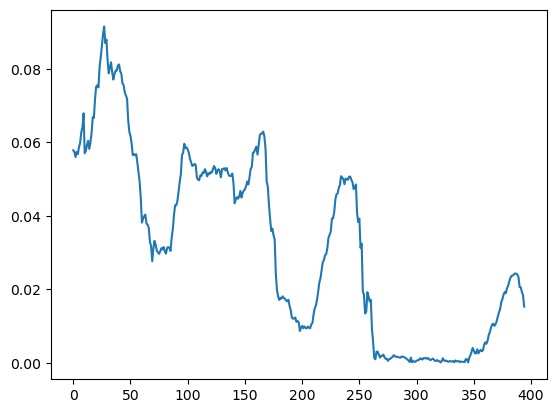

(5, 394) (1, 394)
(5, 394) (1, 394)
(5, 394) (1, 394)
(240,) (240,)


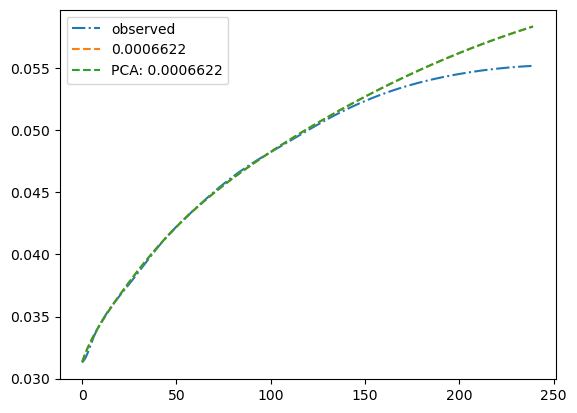

c:\Users\patri\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


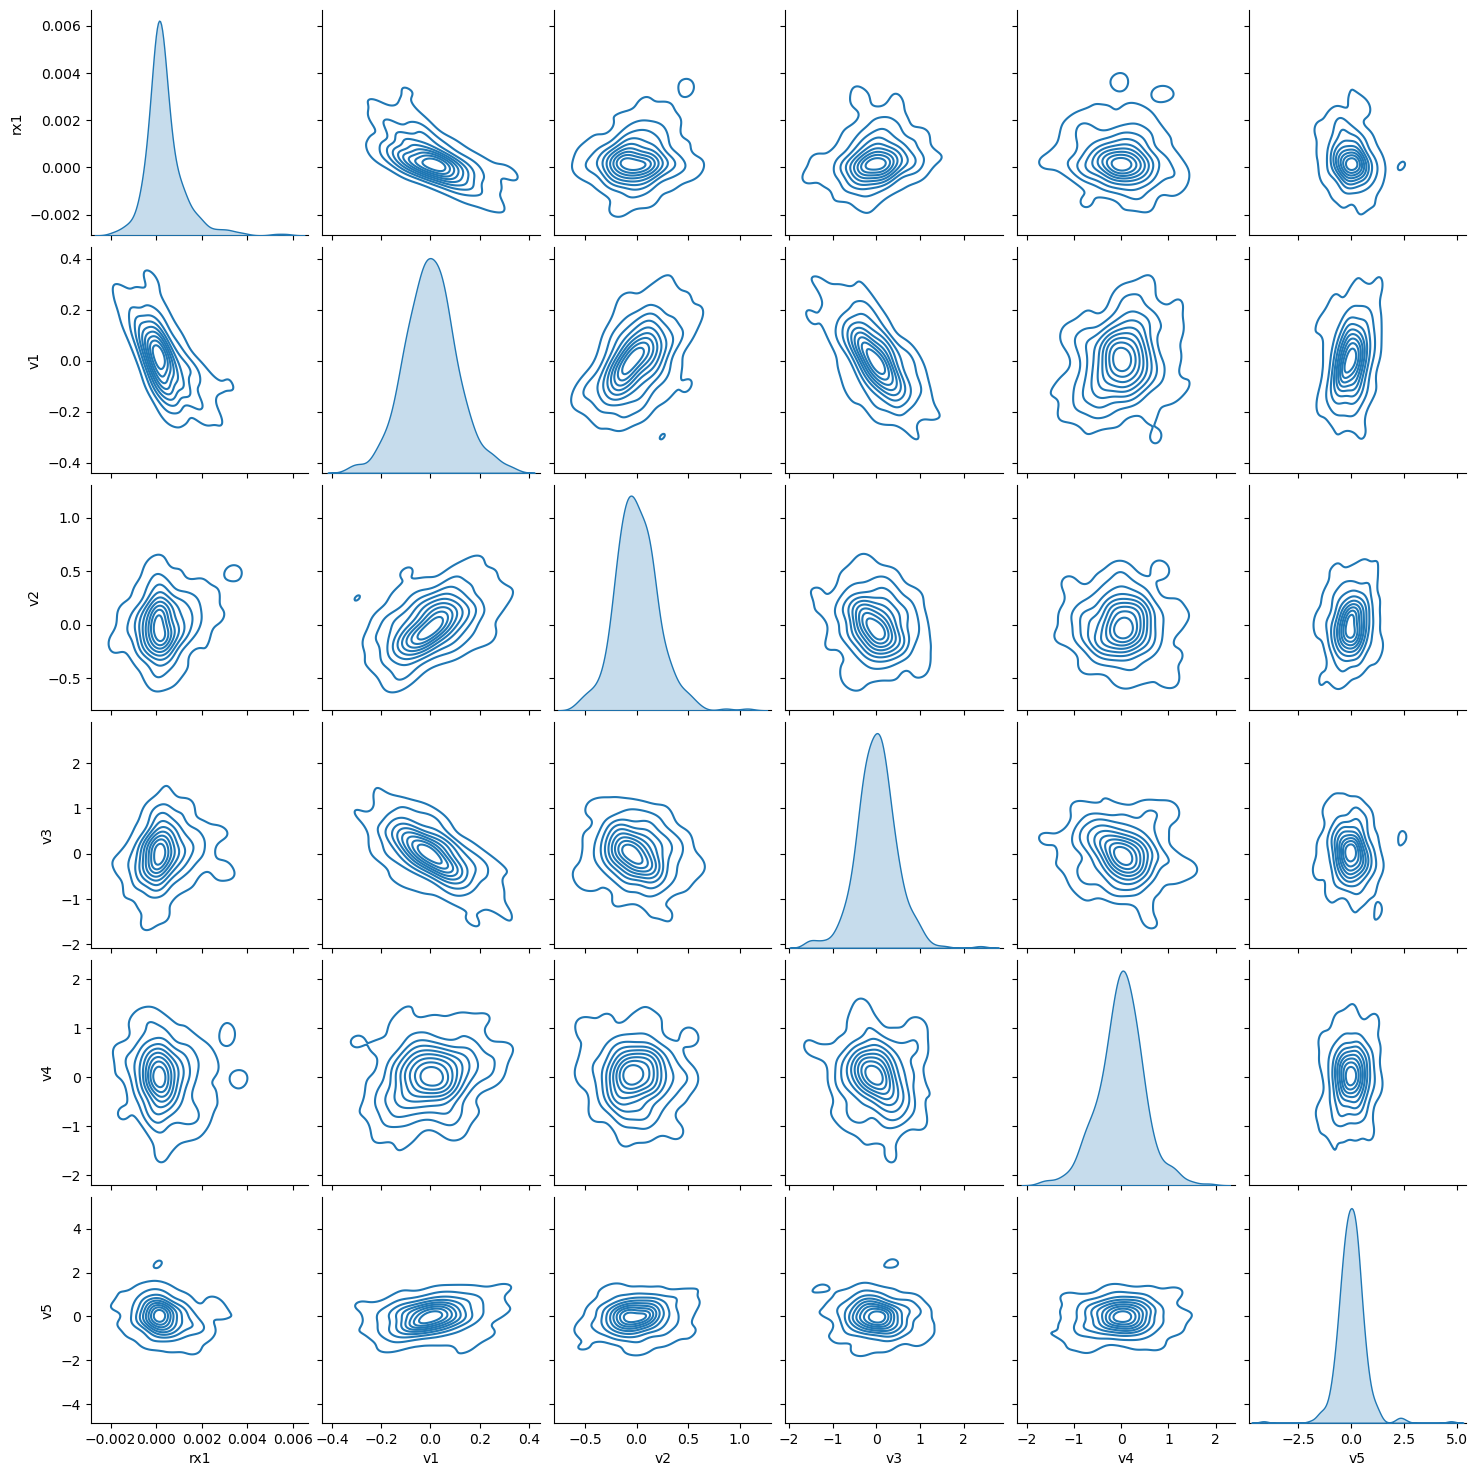

In [ ]:
#plt.plot(reconst[:,0])
plt.plot(df_yields.values[:,2])
plt.show()
results.evaluate_atsm(240, plot_B_v_beta=False)
df_rxv = pd.DataFrame(data=np.vstack((df_rx.values[:,0], results.step1.V_hat)).T, columns=['rx1', 'v1', 'v2', 'v3', 'v4', 'v5'])
import seaborn as sns
sns.pairplot(df_rxv, kind='kde')

Shapiro-Wilk Test for Column 1: Statistic=0.9934951066970825, P-value=0.08798874169588089
Shapiro-Wilk Test for Column 2: Statistic=0.9748929142951965, P-value=2.5012545847857837e-06
Shapiro-Wilk Test for Column 3: Statistic=0.9744276404380798, P-value=2.029438292083796e-06
Shapiro-Wilk Test for Column 4: Statistic=0.985253095626831, P-value=0.00048443180276080966
Shapiro-Wilk Test for Column 5: Statistic=0.8846372365951538, P-value=1.2990957546929005e-16


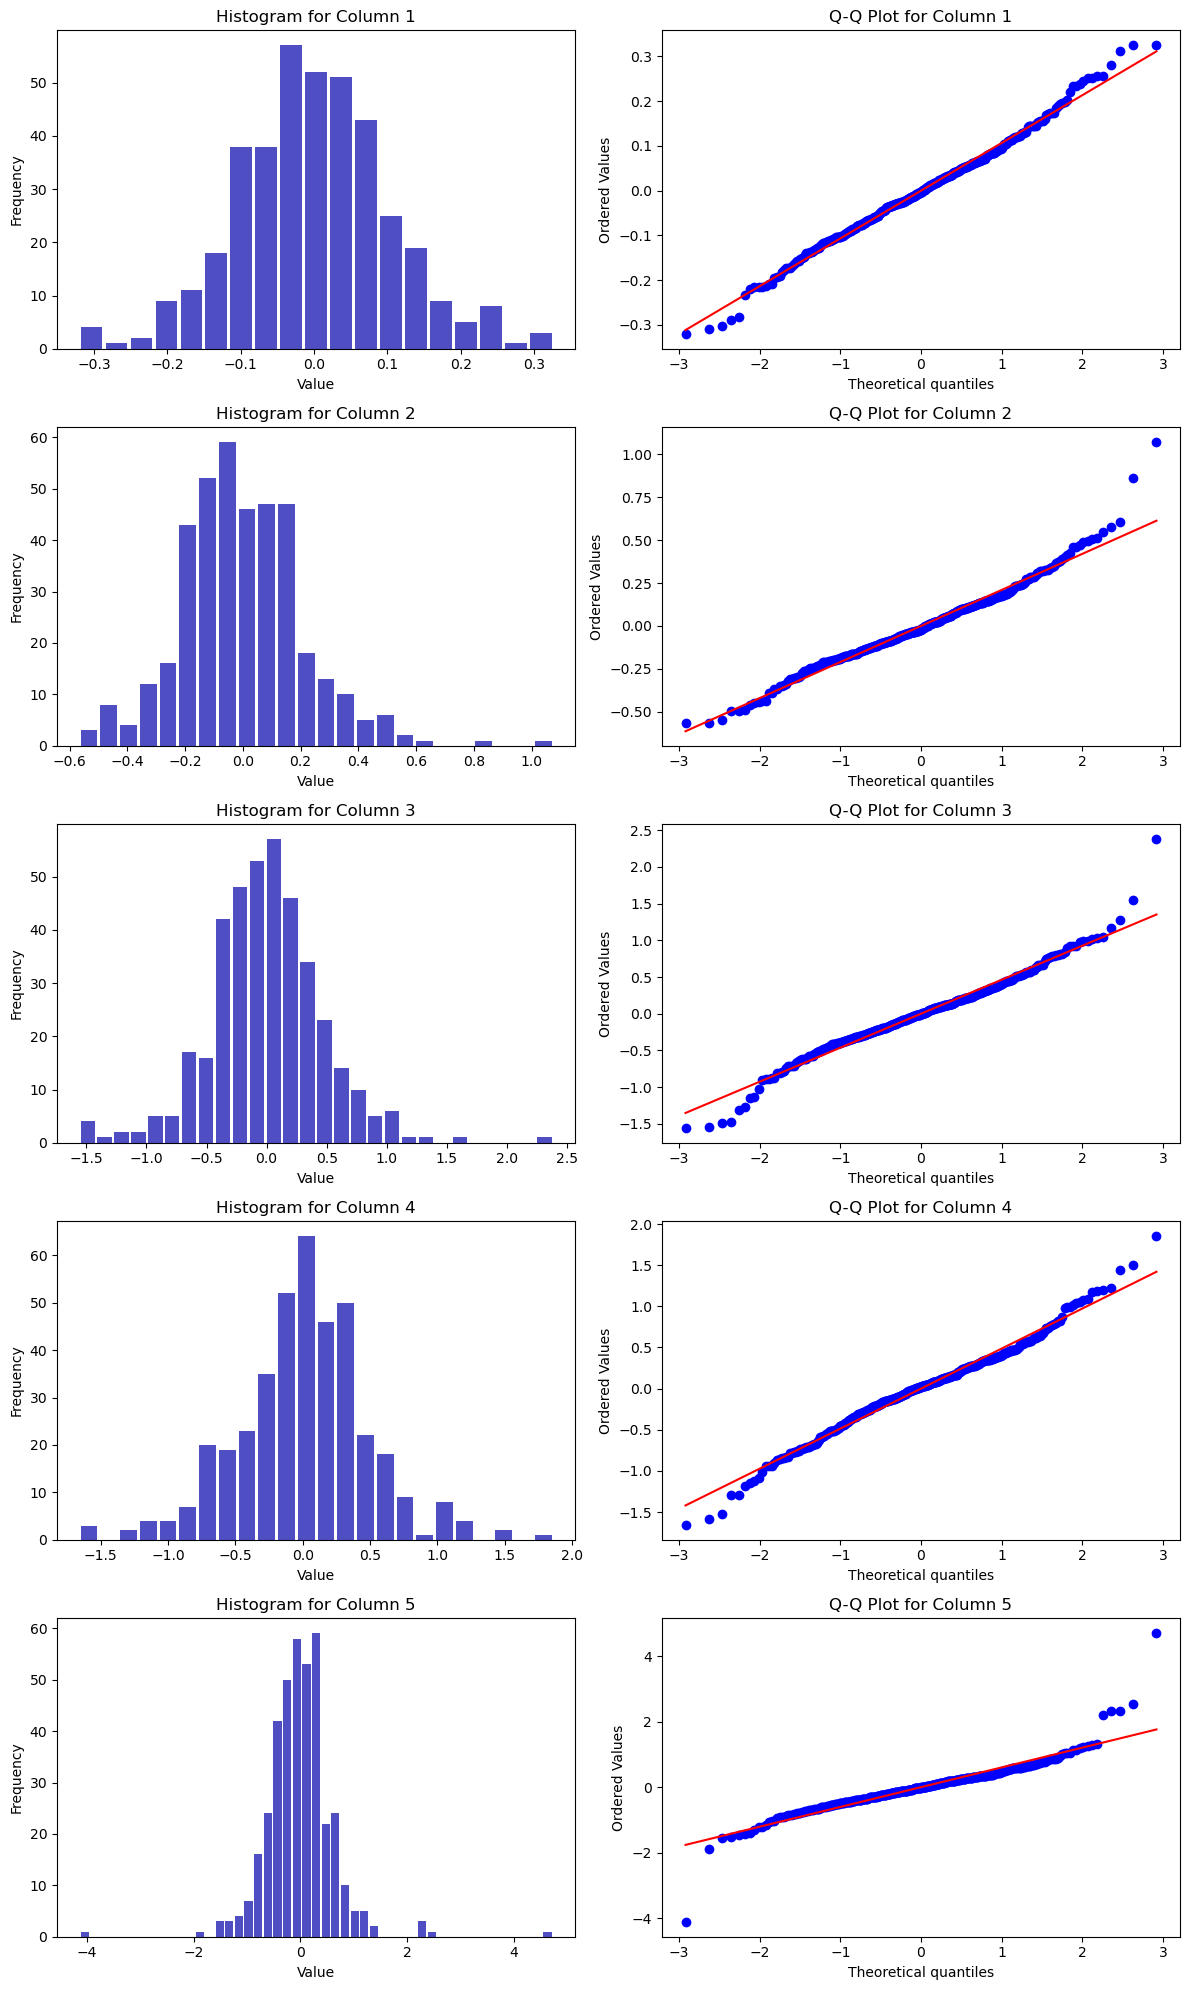

In [ ]:
import seaborn as sns


# Example Usage
# Creating an example NxM matrix (N=100, M=3)

# Assessing normality
assess_normality(results.step1.V_hat.T)



# 1 ESTIMATE eq(1) AND CONSTRUCT VARCOV FROM RESIDUALS

In [ ]:
plt.rcParams['figure.figsize'] = [10, 10]



# 2. REGRESS EXCESS RETURNS ON A CONSTAND, LAGGED PRICING FACTORS (X_) AND CONTEMPORANEOUS PRICING FACTOR INNNOVATIONS $\hat{V}$

# 3 ESTIMATE $\lambda_0$ AND $\lambda_1$

In [ ]:






# Assuming 'df' is your pandas DataFrame with the correct data
# Summary statistics
df_E_hat = pd.DataFrame(data=E_hat[[1, 3,5,9, 10, 11],:].T, columns= ["n = 12", "n = 24", "n = 36" ,"n = 60", "n = 84" ,"n = 120"], index = df_yield_all.iloc[1:,:].index)
summary_stats = df_E_hat.describe().T  # Basic stats
summary_stats['skew'] = df_E_hat.apply(lambda x: skew(x.dropna()))  # Skewness
summary_stats['kurt'] = df_E_hat.apply(lambda x: kurtosis(x.dropna(), fisher=True))  # Kurtosis


# Autocorrelation for lag 1 and lag 6
summary_stats['autocorr_lag1'] = df_E_hat.apply(lambda x: x.autocorr(lag=1))
summary_stats['autocorr_lag6'] = df_E_hat.apply(lambda x: x.autocorr(lag=6))

# Drop unnecessary rows to match the image table format
summary_table = summary_stats.drop(['count', '25%', '50%', '75%', 'min', 'max'], axis=1)

# Renaming columns to match the image table
summary_table.rename(columns={'mean': 'Mean', 'std': 'Standard Deviation', 'skew': 'Skewness',
                              'kurt': 'Kurtosis', 'autocorr_lag1': 'ρ(1)', 'autocorr_lag6': 'ρ(6)'}, inplace=True)

# Display the summary table
#print(summary_stats)
pd.options.display.float_format = '{:.4f}'.format
display(summary_table.T)

NameError: name 'E_hat' is not defined

# PRODUCE YIELD PREDICTIONS

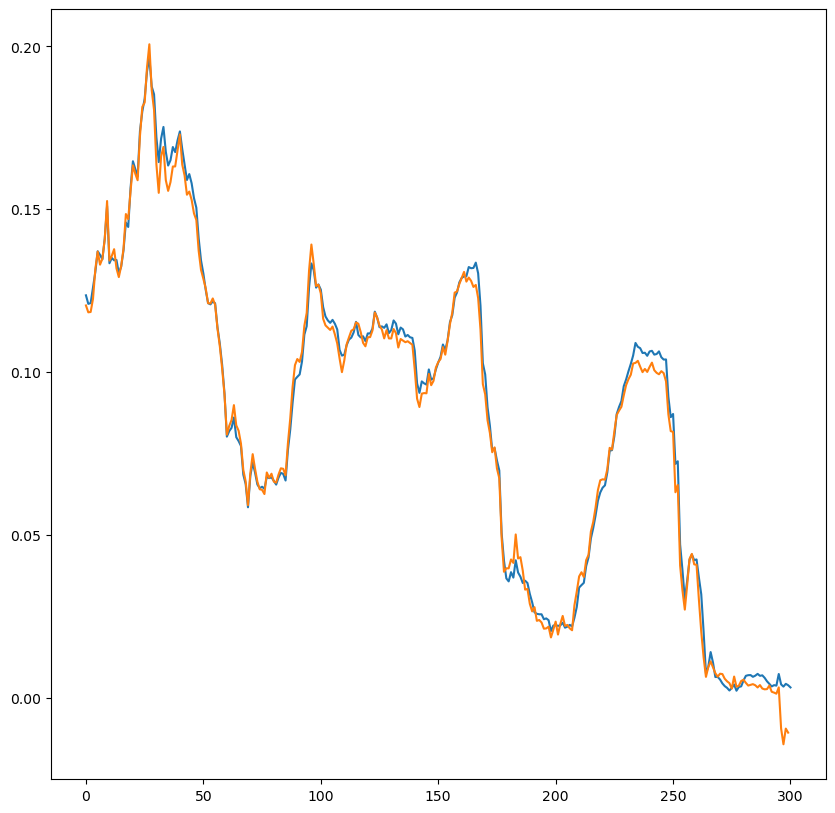

In [ ]:


n = 5
plt.plot(- n*log_prices[f'{n}m'].values.T)
plt.plot(-n*log_prices_fitted[n-1])

-0.39613627974252413


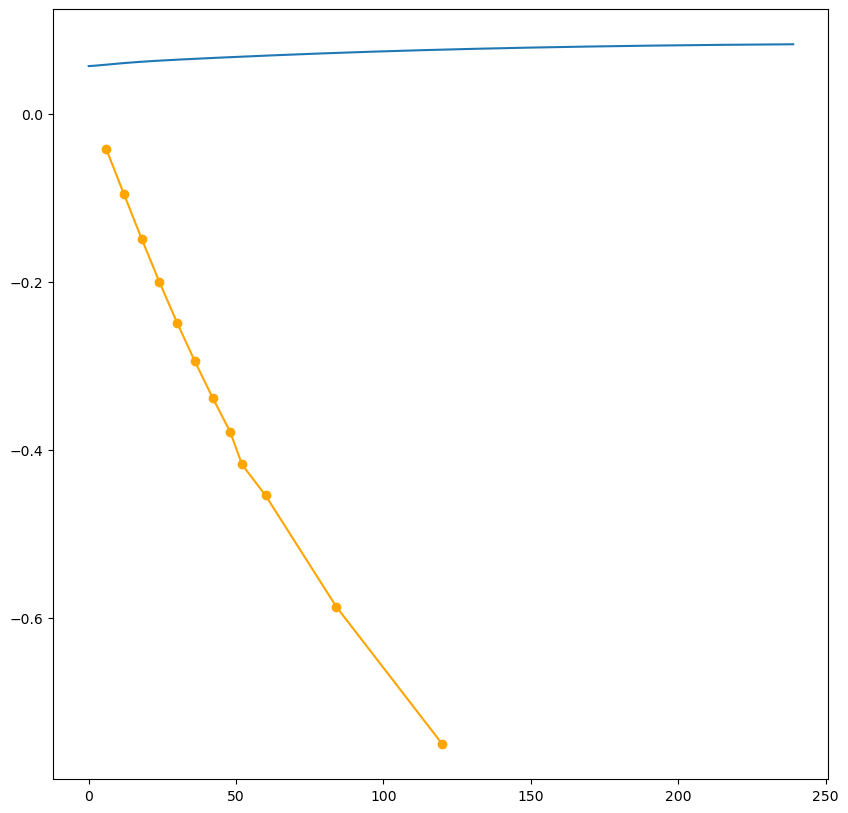

-0.1419085732077721


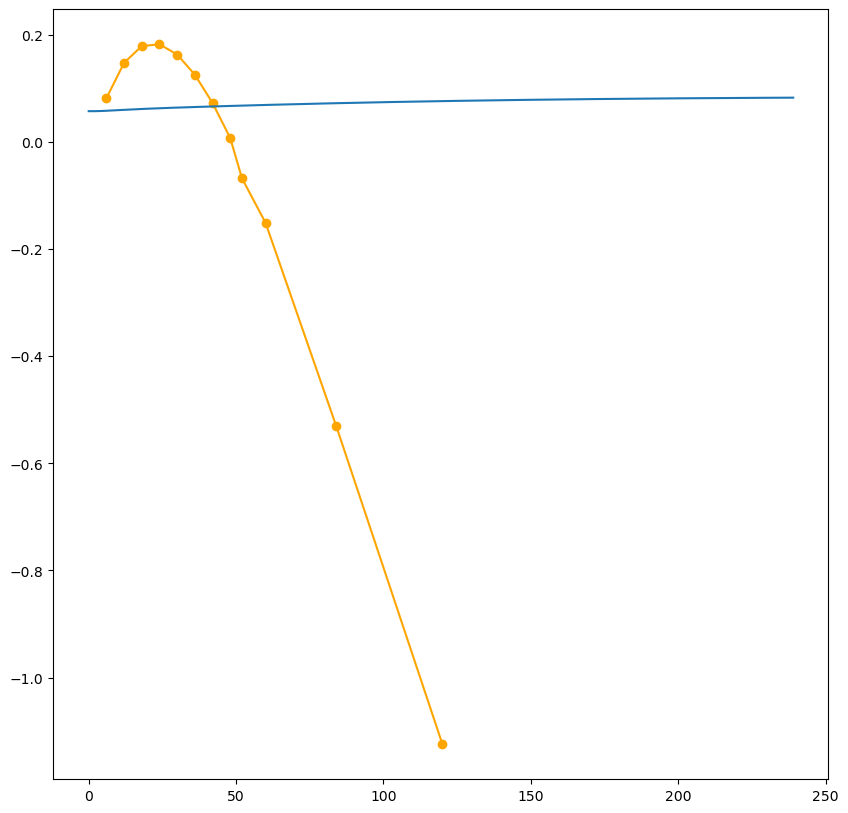

-0.0034000986257202714


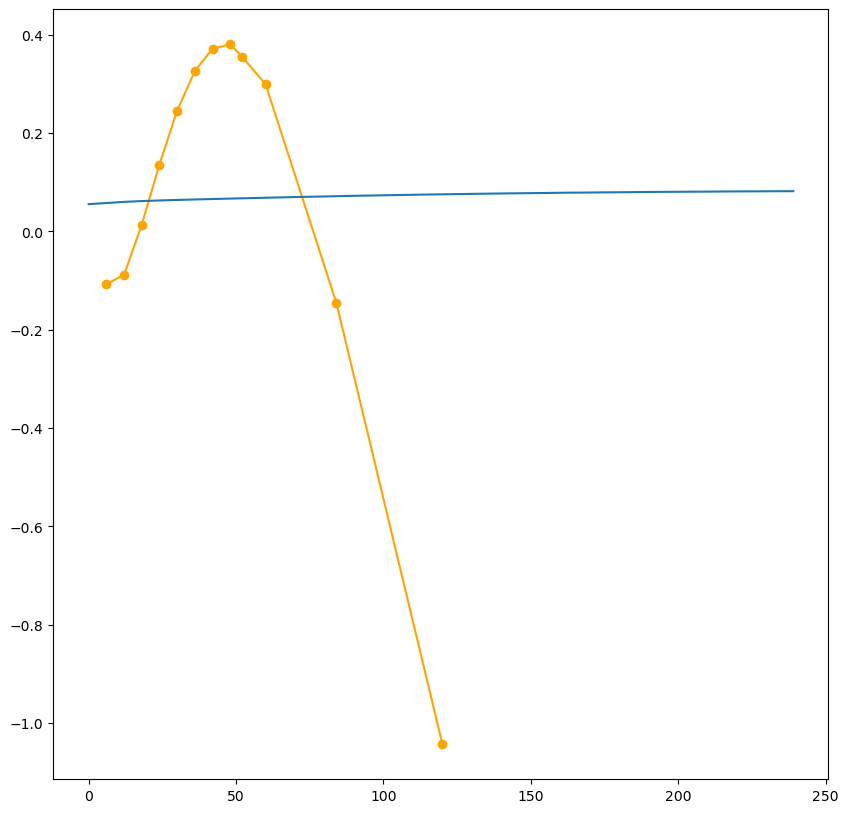

-0.09428456292507326


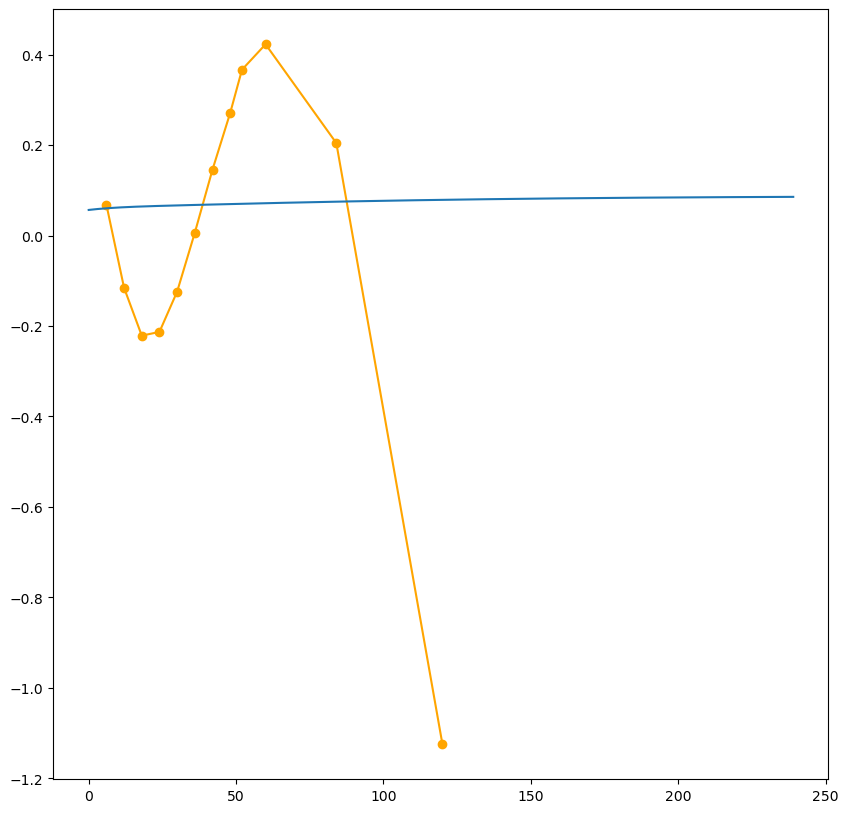

0.017634943675342723


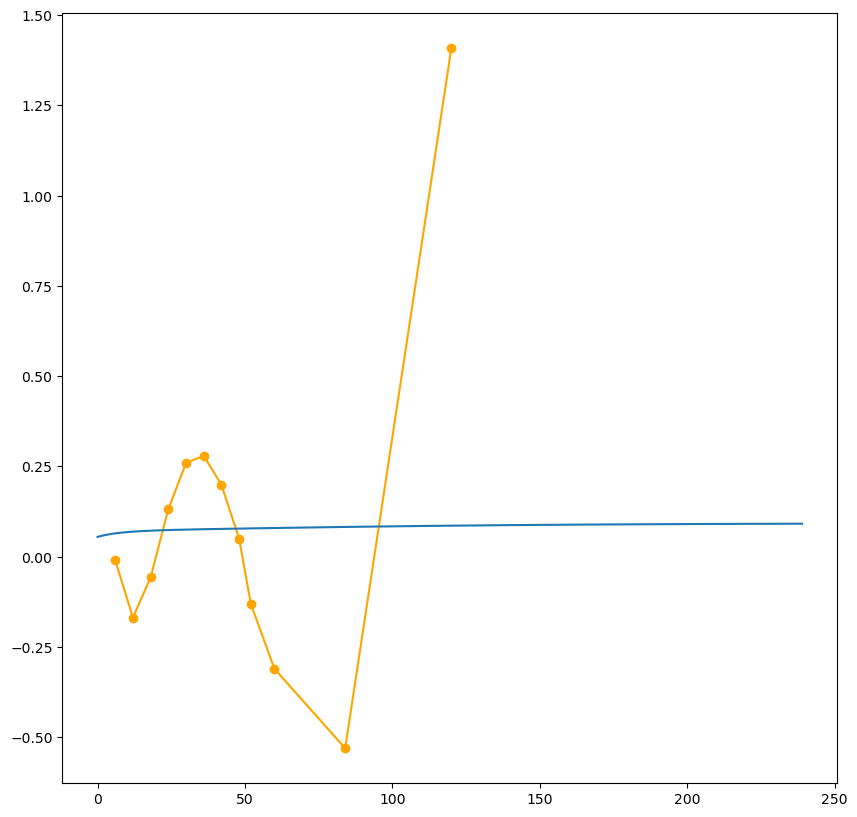

In [ ]:
for i in range(5):
    print(np.mean(beta_hat[i] - B[i,np.array([6,12,18,24,30,36,42,48,52,60,84,120])-1]))
    plt.scatter([6,12,18,24,30,36,42,48,52,60,84,120], beta_hat[i], color='orange')
    plt.plot([6,12,18,24,30,36,42,48,52,60,84,120], beta_hat[i], color='orange')
    plt.plot(B[i])
    plt.show()
    

In [ ]:
with np.printoptions(suppress=True, ):
    print(B[:,rx_maturities-1]-beta_hat)
rx_maturities

ValueError: operands could not be broadcast together with shapes (300,12) (5,12) 

In [ ]:
with np.printoptions(suppress=True, ):
    print(beta_hat)

[[-0.042 -0.096 -0.149 -0.2   -0.249 -0.294 -0.338 -0.379 -0.417 -0.454
  -0.587 -0.751]
 [ 0.081  0.147  0.179  0.182  0.163  0.125  0.072  0.007 -0.068 -0.151
  -0.531 -1.124]
 [-0.107 -0.088  0.014  0.136  0.246  0.326  0.372  0.381  0.355  0.299
  -0.145 -1.043]
 [ 0.068 -0.116 -0.221 -0.213 -0.124  0.006  0.146  0.271  0.367  0.423
   0.204 -1.125]
 [-0.01  -0.169 -0.057  0.132  0.26   0.28   0.2    0.05  -0.131 -0.31
  -0.53   1.408]]
